In [127]:
%load_ext autoreload
%autoreload 2

Failed to reload module 'benchmark.cloud_model' from file '/Users/hangzegao/PycharmProjects/cloud/MyCloudSenseNet/benchmark/cloud_model.py'
Traceback (most recent call last):
  File "/Users/hangzegao/PycharmProjects/cloud/.venv/lib/python3.14/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/hangzegao/PycharmProjects/cloud/.venv/lib/python3.14/site-packages/IPython/extensions/autoreload.py", line 584, in superreload
    module = reload(module)
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/importlib/__init__.py", line 129, in reload
    _bootstrap._exec(spec, module)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 869, in _exec
  File "<frozen importlib._bootstrap_external>", line 762, in exec_module
  File "<frozen importlib._bootstrap>", line 491, in _call_with_frames_removed
  File "/Users/hangzegao/Pych

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[autoreload of benchmark.cloud_model failed: Traceback (most recent call last):
  File "/Users/hangzegao/PycharmProjects/cloud/.venv/lib/python3.14/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/hangzegao/PycharmProjects/cloud/.venv/lib/python3.14/site-packages/IPython/extensions/autoreload.py", line 584, in superreload
    module = reload(module)
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/importlib/__init__.py", line 129, in reload
    _bootstrap._exec(spec, module)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 869, in _exec
  File "<frozen importlib._bootstrap_external>", line 762, in exec_module
  File "<frozen importlib._bootstrap>", line 491, in _call_with_frames_removed
  File "/Users/hangzegao/PycharmProjects/cloud/MyCloudSenseNet/benchmark/cloud_model.py", line 15, in <module>
    from MyCl

In [128]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [129]:
DATA_DIR = Path.cwd().parent.resolve() / "data"

dataset = "download"

img_in_dir = DATA_DIR / f"{dataset}/images"
mask_in_dir = DATA_DIR / f"{dataset}/masks"

img_out_dir = DATA_DIR / f"images/{dataset}"
label_out_dir = DATA_DIR / f"labels/{dataset}"

csv_out_dir = DATA_DIR / "metadata"
metadata_path = csv_out_dir / f"{dataset}_metadata.csv"

In [130]:
img_out_dir.mkdir(parents=True, exist_ok=True)
label_out_dir.mkdir(parents=True, exist_ok=True)
csv_out_dir.mkdir(parents=True, exist_ok=True)

In [131]:
def mask2label(mask):
    label = np.zeros_like(mask, dtype=np.uint8)
    label[(mask >= 0) & (mask <= 10)] = 0  # background
    label[(mask >= 20) & (mask <= 200)] = 1  # shadow
    label[(mask >= 250) & (mask <= 255)] = 2  # cloud
    return label

In [132]:
def normalize_by_minmax(data, max_pixel=1):
    min_val = float(np.nanmin(data))
    max_val = float(np.nanmax(data))
    range_val = max_val - min_val
    if range_val == 0:
        return data.copy()
    data = (data.copy() - min_val) / range_val
    data *= max_pixel
    return data

In [133]:
def generate_pseudo_nir_with_ndvi(b: np.ndarray, g: np.ndarray, r: np.ndarray, label: np.ndarray = None) -> np.ndarray:
    b = b.astype(np.float32)
    g = g.astype(np.float32)
    r = r.astype(np.float32)

    ndvi = (2 * g - r - b) / (2 * g + r + b)

    nir = r * (1 + ndvi) / (1 - ndvi)
    return normalize_by_minmax(nir, 255).astype(np.uint8)

def generate_pseudo_nir(b: np.ndarray, g: np.ndarray, r: np.ndarray, label: np.ndarray = None) -> np.ndarray:
    """
    基于云特征突出的伪NIR通道生成算法

    策略原理:
    1. 云在可见光波段(特别是红波段)有高反射率，在NIR波段反射率更高
    2. 使用红波段作为NIR的基础估计
    3. 结合亮度信息和云标签进行自适应增强
    4. 对云区域增强，对非云区域适度抑制

    参数:
        rgb_array: RGB图像数组 (H, W, 3) 或 (3, H, W)，值范围 [0, 255]
        label: 云标签 (H, W)，可选，用于指导增强

    返回:
        pseudo_nir: 伪NIR通道 (H, W)，uint16类型
    """
    # 处理输入维度

    r = r.astype(np.float32)
    g = g.astype(np.float32)
    b = b.astype(np.float32)

    # 计算亮度 (Luminance) - 云的指示器
    luminance = 0.299 * r + 0.587 * g + 0.114 * b

    # 计算白度 (Whiteness) - 云通常是白色的
    # 使用RGB标准差，云的标准差较小（更白）
    rgb_mean = (r + g + b) / 3.0
    rgb_std = np.sqrt(((r - rgb_mean)**2 + (g - rgb_mean)**2 + (b - rgb_mean)**2) / 3.0 + 1e-6)
    whiteness = 1.0 - (rgb_std / 128.0)  # 归一化，越白值越大
    whiteness = np.clip(whiteness, 0, 1)

    # 基于红波段的NIR基础估计
    # 云在红波段反射率约为0.3-0.5，在NIR约为0.6-0.9
    nir_base = r * 1.5  # 基础放大

    # 云特征增强因子
    # 策略：亮度高+白度高 = 很可能是云 -> 大幅增强NIR值
    #      亮度低 = 地表/水体 -> 适度增强或抑制

    # 亮度权重：高亮度区域得到更多增强
    brightness_weight = np.power(luminance / 255.0, 0.7)  # 非线性增强亮区

    # 白度权重：白色区域（云）得到额外增强
    cloud_weight = np.power(whiteness, 2.0)  # 强调白度

    # 综合增强因子
    enhancement = 1.0 + brightness_weight * 0.5 + cloud_weight * 0.8

    # 如果有标签信息，使用标签进行精细调整
    if label is not None:
        # 标签区域：云(1)进一步增强，非云(0)适度抑制
        label_weight = np.where(label == 1, 1.3, 0.9)
        enhancement = enhancement * label_weight

    # 应用增强
    pseudo_nir = nir_base * enhancement

    # 添加基于纹理的细节（模拟真实NIR的纹理特征）
    # 使用蓝波段和红波段的差异来估计植被/水体特征
    br_diff = b - r  # 蓝减红，负值表示植被（叶绿素吸收红波段）
    vegetation_factor = np.clip(1.0 - np.abs(br_diff) / 255.0, 0.5, 1.0)

    # 植被区域适度降低NIR（虽然真实NIR植被也高，但为了突出云，这里做对比）
    pseudo_nir = pseudo_nir * vegetation_factor

    # 归一化到uint16范围 [0, 65535]，模拟Sentinel-2/Landsat的NIR值
    # 实际云在NIR的反射率通常在0.4-0.9，对应约 26000-59000
    pseudo_nir = np.clip(pseudo_nir / 255.0 * 80000, 0, 65535)

    return normalize_by_minmax(pseudo_nir, 255).astype(np.uint8)

In [134]:
def convert_to_B02_B03_B04_B08_Mask(path: str | Path, mask_in_dir: str | Path, img_out_dir: str | Path, label_out_dir: str | Path, show: bool = False):
    metadata = []
    path = Path(path)
    if path.is_dir():
        # Process directory
        im_files = [f for ext in ("tif", "tiff", "png", "jpg") for f in path.rglob(f"*.{ext}")]
        for im_path in im_files:
            metadata.append(convert_to_B02_B03_B04_B08_Mask(im_path, mask_in_dir, img_out_dir, label_out_dir, show))
        return metadata
    else:
        # Process a single image
        filename = path.stem
        bgr = cv2.imread(str(path))
        height, width = bgr.shape[:2]

        chip_out_dir = Path(img_out_dir) / filename
        chip_out_dir.mkdir(parents=True, exist_ok=True)
        row = {
            "chip_id": filename,
            "location": "E0.0-N0.0",
            "datetime": "2020/02/02",
            "x_start": 0,
            "x_end": width,
            "y_start": 0,
            "y_end": height,
            "B02_path": f"{str(chip_out_dir)}/B02.tif",
            "B03_path": f"{str(chip_out_dir)}/B03.tif",
            "B04_path": f"{str(chip_out_dir)}/B04.tif",
            "B08_path": f"{str(chip_out_dir)}/B08.tif",
            "label_path": f"{str(label_out_dir)}/{filename}.tif",
        }

        # Interpolate all pixels at once
        # n_channels = 1
        # bgr_wavelengths = np.array([497, 560, 665])  # B, G, R wavelengths (nm)
        # target_wavelengths = np.linspace(835, 835, n_channels) # NIR wavelength range (nm)
        # f = interp1d(bgr_wavelengths.T, bgr, kind="linear", bounds_error=False, fill_value="extrapolate")
        # multispectral = f(target_wavelengths)
        # nir = np.clip(multispectral, 0, 255).astype(np.uint8)

        b = bgr[:, :, 0]
        g = bgr[:, :, 1]
        r = bgr[:, :, 2]
        nir = np.clip(0.0 * r + 0.2 * g + 0.8 * b, 0, 255).astype(np.uint8)
        # nir = generate_pseudo_nir_with_ndvi(b, g, r, None)

        cv2.imwrite(row["B02_path"], b)
        cv2.imwrite(row["B03_path"], g)
        cv2.imwrite(row["B04_path"], r)
        cv2.imwrite(row["B08_path"], nir)

        mask = cv2.imread(str(mask_in_dir / path.name), cv2.IMREAD_GRAYSCALE)
        if mask:
            mask = mask2label(mask)
            cv2.imwrite(row["label_path"], mask)

        if show:
            plt.figure(figsize=(12, 6))

            plt.subplot(1, 2, 1)
            plt.imshow(bgr)
            plt.title("Original RGB Image", fontsize=14)
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(nir, cmap='hot')
            plt.title("Generated NIR Image (835nm)", fontsize=14)
            plt.axis('off')

            plt.tight_layout()
            plt.show()

        return row

In [135]:
metadata = convert_to_B02_B03_B04_B08_Mask(img_in_dir, mask_in_dir, img_out_dir, label_out_dir)
pd.DataFrame(metadata).to_csv(metadata_path, index=False)
metadata[0]

[ WARN:0@84940.779] global loadsave.cpp:278 findDecoder imread_('/Users/hangzegao/PycharmProjects/cloud/data/download/masks/GF6_PMS_E79.7_N35.0_20260513_L1A1420708788.jpg'): can't open/read file: check file path/integrity
[ WARN:0@84940.833] global loadsave.cpp:278 findDecoder imread_('/Users/hangzegao/PycharmProjects/cloud/data/download/masks/GF1_PMS2_E75.6_N40.7_20260512_L1A14401389001.jpg'): can't open/read file: check file path/integrity
[ WARN:0@84940.885] global loadsave.cpp:278 findDecoder imread_('/Users/hangzegao/PycharmProjects/cloud/data/download/masks/GF1_PMS2_E115.6_N30.7_20260513_L1A14402621001.jpg'): can't open/read file: check file path/integrity
[ WARN:0@84940.934] global loadsave.cpp:278 findDecoder imread_('/Users/hangzegao/PycharmProjects/cloud/data/download/masks/GF1_PMS1_E115.7_N32.5_20260513_L1A14402735001.jpg'): can't open/read file: check file path/integrity
[ WARN:0@84941.006] global loadsave.cpp:278 findDecoder imread_('/Users/hangzegao/PycharmProjects/cloud/

{'chip_id': 'GF6_PMS_E79.7_N35.0_20260513_L1A1420708788',
 'location': 'E0.0-N0.0',
 'datetime': '2020/02/02',
 'x_start': 0,
 'x_end': 1098,
 'y_start': 0,
 'y_end': 1011,
 'B02_path': '/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF6_PMS_E79.7_N35.0_20260513_L1A1420708788/B02.tif',
 'B03_path': '/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF6_PMS_E79.7_N35.0_20260513_L1A1420708788/B03.tif',
 'B04_path': '/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF6_PMS_E79.7_N35.0_20260513_L1A1420708788/B04.tif',
 'B08_path': '/Users/hangzegao/PycharmProjects/cloud/data/images/download/GF6_PMS_E79.7_N35.0_20260513_L1A1420708788/B08.tif',
 'label_path': '/Users/hangzegao/PycharmProjects/cloud/data/labels/download/GF6_PMS_E79.7_N35.0_20260513_L1A1420708788.tif'}

In [136]:
from pathlib import Path

from loguru import logger
import pandas as pd
from PIL import Image
import torch

from benchmark.cloud_dataset import CloudDataset
from benchmark.cloud_model import CloudModel

BANDS = ["B02", "B03", "B04", "B08"]
MODEL_NAME = "unet"

def predict_chips(test_feature_path: Path, pred_out_dir: Path, fast_dev_run: bool = False):
        logger.info("Loading model weights")
        model_weights_path: Path = Path(f"benchmark/{MODEL_NAME}/assets/cloud_model.pt")

        logger.info("Loading model")
        model = CloudModel(bands=BANDS,
                           hparams={"weights": None},
                           model_name=MODEL_NAME,)
        model.load_state_dict(torch.load(model_weights_path))

        logger.info("Loading metadata")
        x_paths = pd.read_csv(test_feature_path)
        if fast_dev_run:
            x_paths = x_paths.head(model.num_workers * model.num_workers)
        logger.info(f"Found {len(x_paths)} chips")

        dataset = CloudDataset(x_paths=x_paths, bands=BANDS, bit_depth=8)
        dataloader = torch.utils.data.DataLoader(dataset,
                                                 batch_size=1,
                                                 num_workers=0,
                                                 pin_memory=False)

        logger.info("Generating predictions in batches")
        for batch_index, batch in enumerate(dataloader):
            logger.debug(f"Predicting batch {batch_index} of {len(dataloader)}")
            device = next(model.parameters()).device
            x = batch["chip"].to(device)
            model.eval()
            with torch.no_grad():
                preds = model(x)
                preds = torch.argmax(preds, dim=1).cpu().numpy().astype("uint8")
            # preds = model.forward(x)
            # preds = torch.softmax(preds, dim=1)[:, 1]
            # preds = (preds > 0.5).detach().numpy().astype("uint8")
            # preds = torch.argmax(preds, dim=1).detach().numpy().astype("uint8")
            for chip_id, pred in zip(batch["chip_id"], preds):
                chip_pred_path = pred_out_dir / f"{chip_id}.tif"
                chip_pred_im = Image.fromarray(pred)
                chip_pred_im.save(chip_pred_path)

        logger.info(f"""Saved {len(list(pred_out_dir.glob("*.tif")))} predictions""")


In [140]:
from pathlib import Path
import random

data_dir = Path.cwd().parent.resolve() / "data"

dataset = "download"
# dataset = "oncloudn"

img_in_dir = data_dir / f"images/{dataset}"
label_out_dir = data_dir / f"labels/{dataset}"
csv_out_dir = data_dir / "metadata"
pred_out_dir = data_dir / f"predictions/{dataset}"
pred_out_dir.mkdir(exist_ok=True, parents=True)

metadata_path = csv_out_dir / f"{dataset}_metadata.csv"

logger.info("Generating predictions in batches")
predict_chips(metadata_path, pred_out_dir)
logger.info(f"""Saved {len(list(pred_out_dir.glob("*.tif")))} predictions""")

2026-05-27 08:48:36.468 | INFO     | __main__:<module>:17 - Generating predictions in batches
2026-05-27 08:48:36.468 | INFO     | __main__:predict_chips:15 - Loading model weights
2026-05-27 08:48:36.469 | INFO     | __main__:predict_chips:18 - Loading model
2026-05-27 08:48:36.995 | INFO     | __main__:predict_chips:24 - Loading metadata
2026-05-27 08:48:36.999 | INFO     | __main__:predict_chips:28 - Found 11 chips
2026-05-27 08:48:37.000 | INFO     | __main__:predict_chips:36 - Generating predictions in batches
/Users/hangzegao/PycharmProjects/cloud/.venv/lib/python3.14/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
2026-05-27 08:48:37.052 | DEBUG    | __main__:predict_chips:38 - Predicting batch 0 of 11
2026-05-27 08:48:37.587 | DEBUG    | __main__:predict_chips:38 - Predicting batch 1

In [141]:
import xarray
import xrspatial.multispectral as ms

def get_xarray(filepath):
    """Put images in xarray.DataArray format"""
    im_arr = np.array(Image.open(filepath))
    return xarray.DataArray(im_arr, dims=["y", "x"])

def true_color_img(B02_path, B03_path, B04_path):
    """Given the path to the directory of Sentinel-2 chip feature images,
    plots the true color image"""
    red = get_xarray(B04_path)
    green = get_xarray(B03_path)
    blue = get_xarray(B02_path)

    return ms.true_color(r=red, g=green, b=blue, c=5, th=0.3)

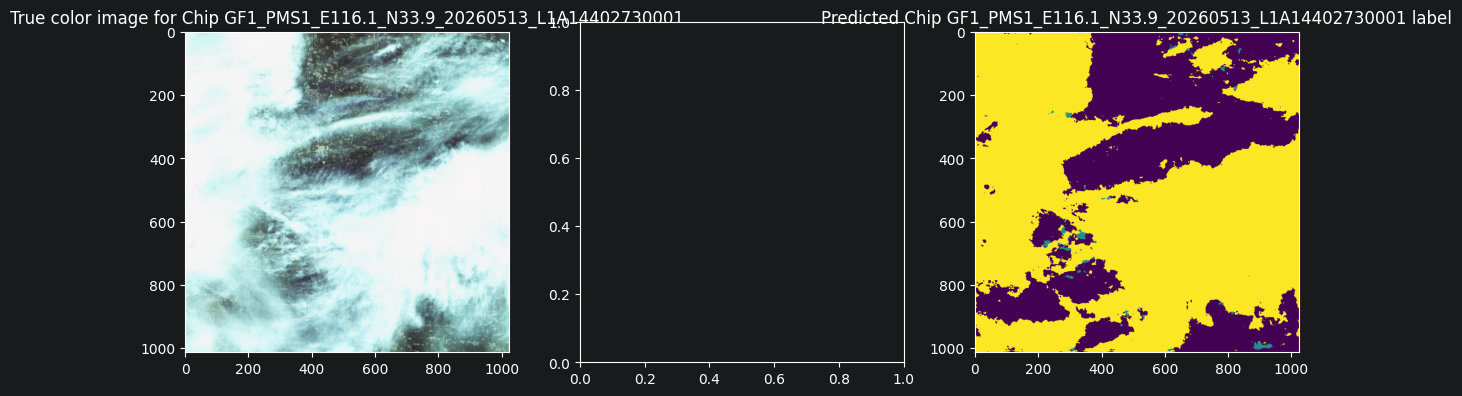

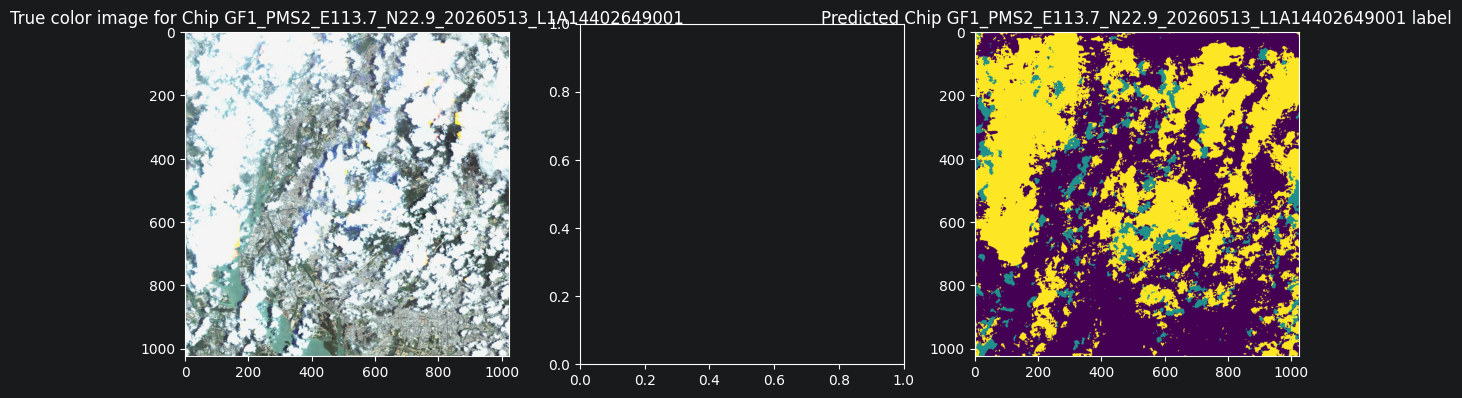

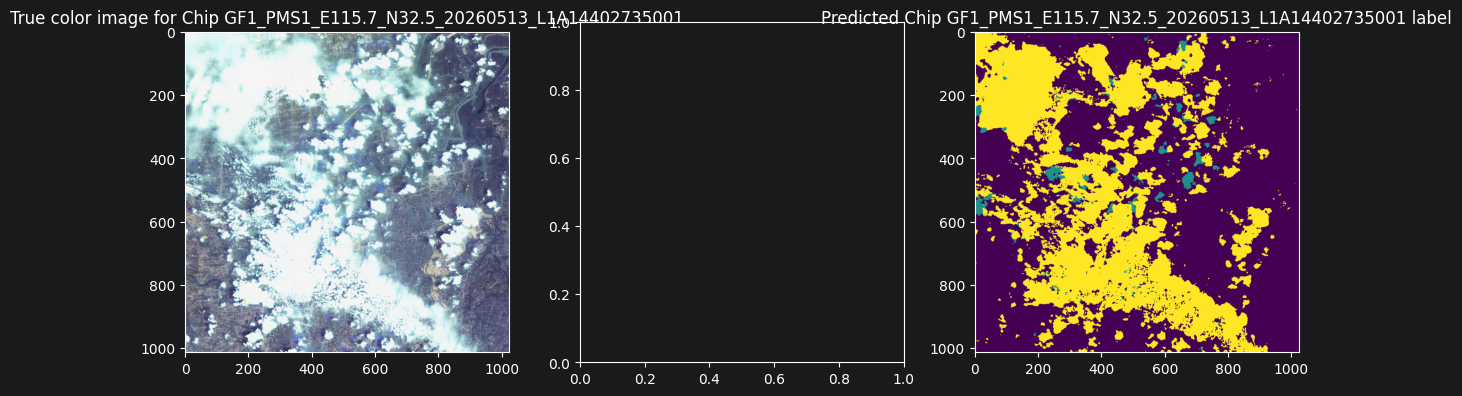

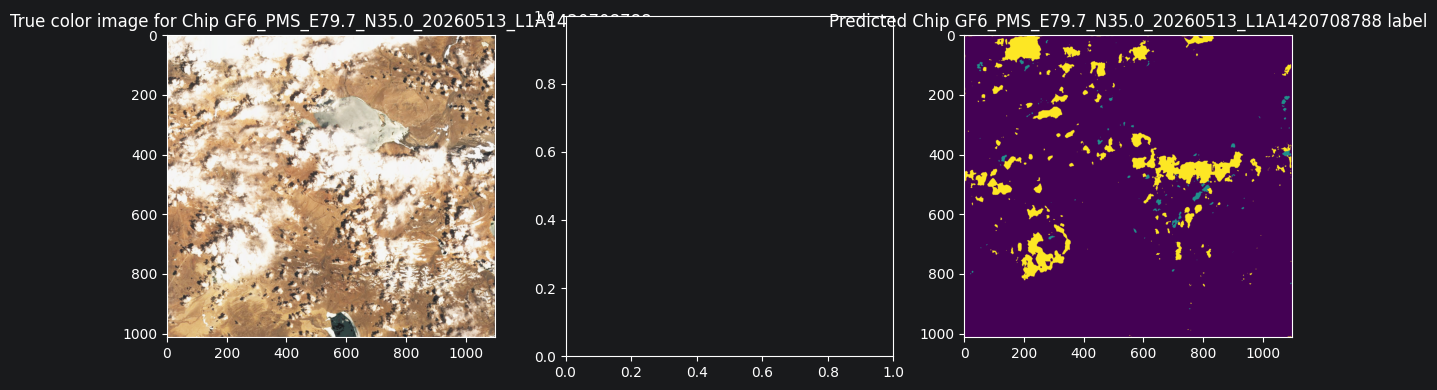

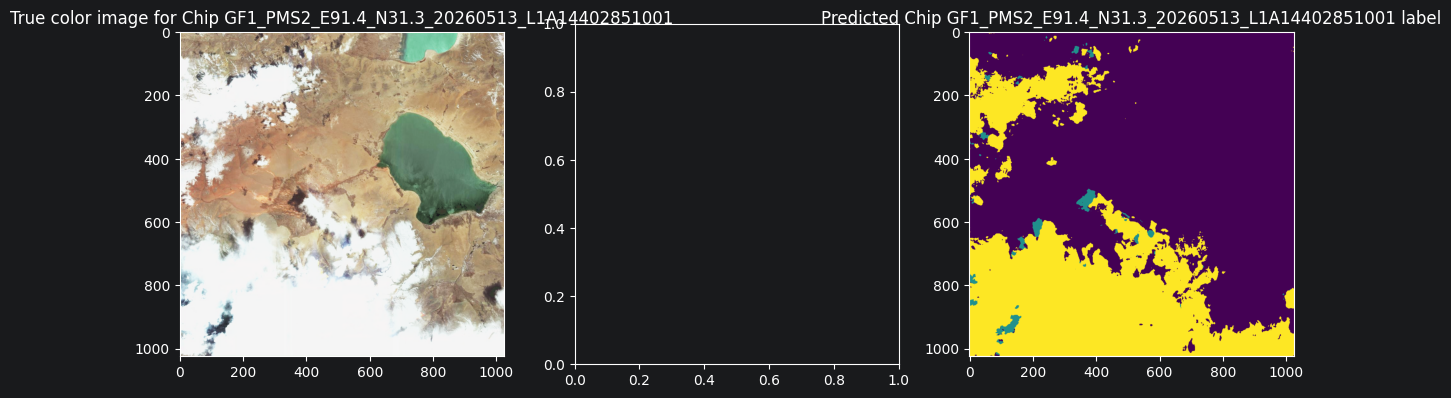

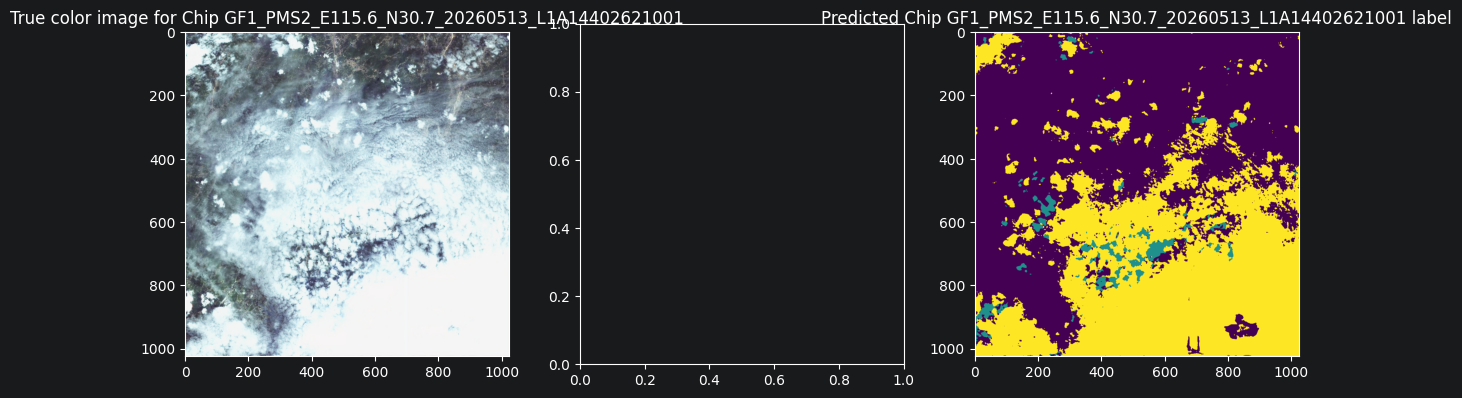

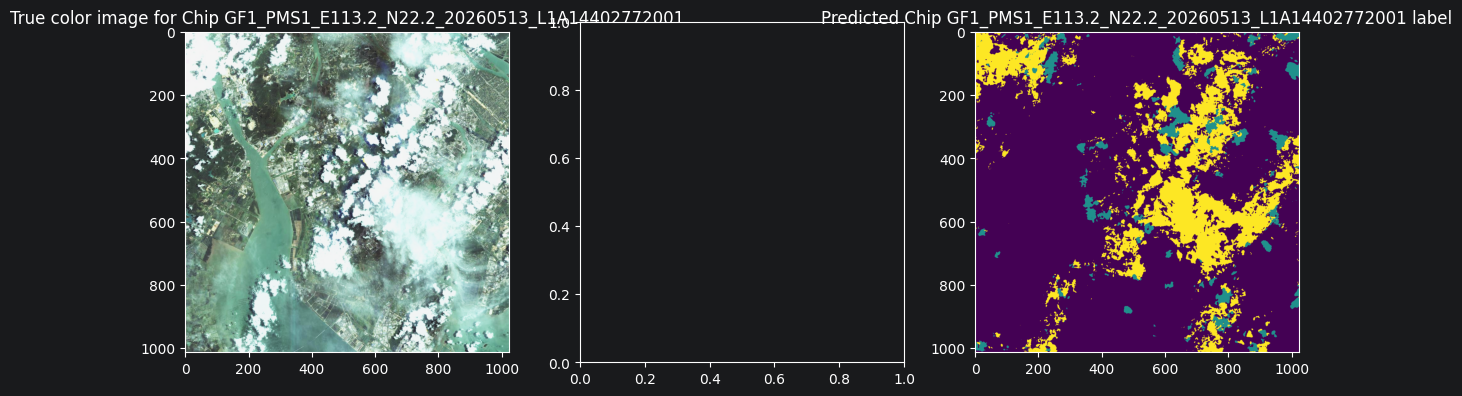

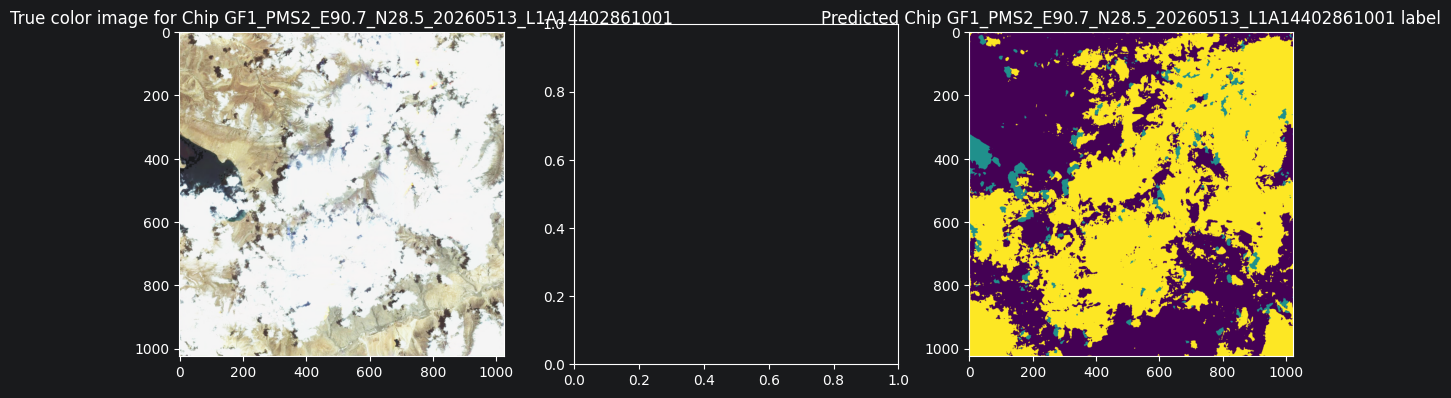

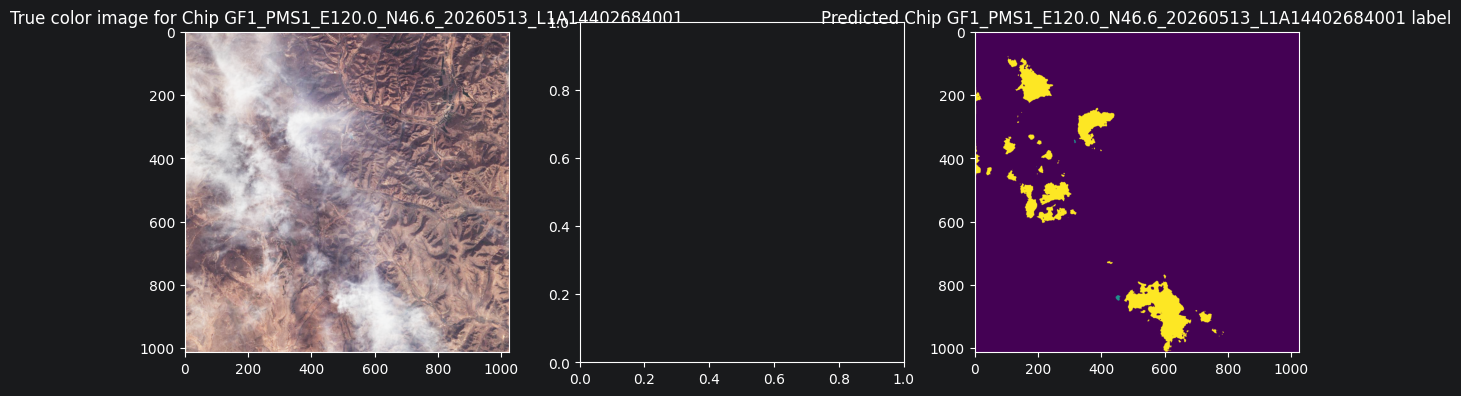

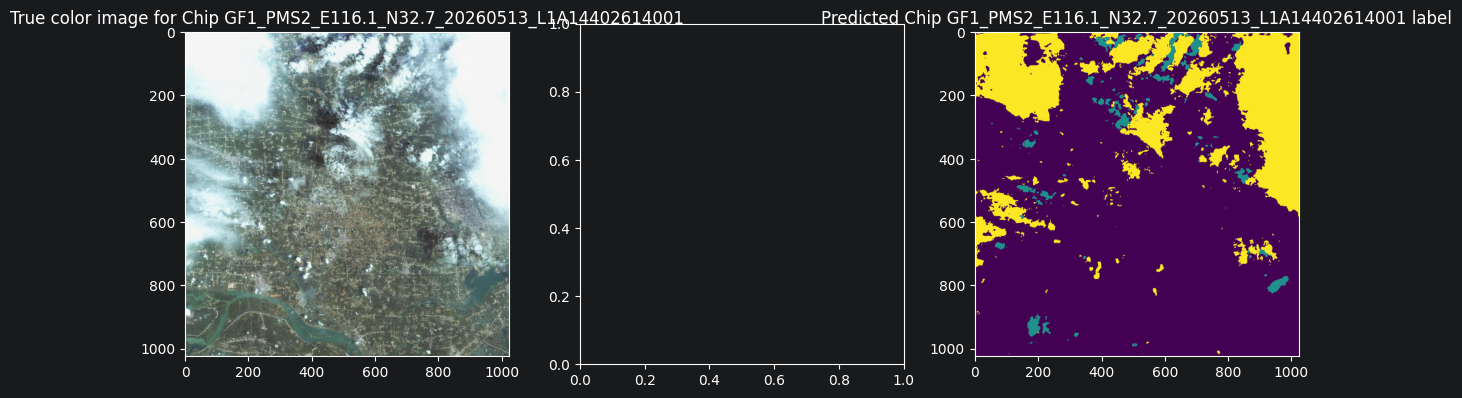

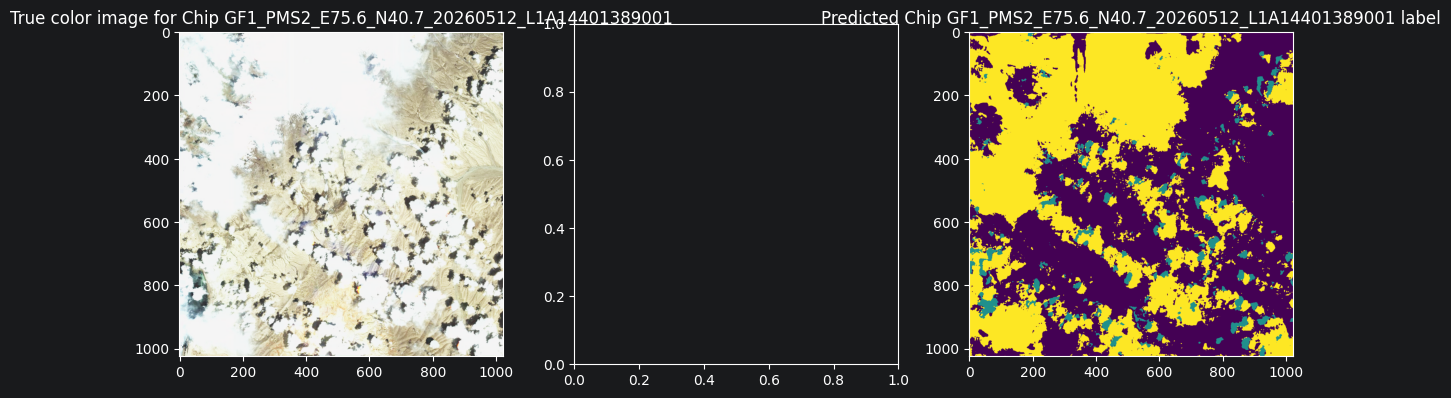

In [142]:
files = list(pred_out_dir.glob("*.tif"))

pred_files = random.sample(files, len(files))
for pred_file in pred_files:
    B02_file = img_in_dir / pred_file.stem / "B02.tif"
    B03_file = img_in_dir / pred_file.stem / "B03.tif"
    B04_file = img_in_dir / pred_file.stem / "B04.tif"
    label_file = label_out_dir / pred_file.name

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    if B02_file.exists():
        ax[0].imshow(true_color_img(B02_file, B03_file, B04_file))
        ax[0].set_title(f"True color image for Chip {label_file.stem}")
    if label_file.exists():
        label = Image.open(label_file)
        ax[1].imshow(label)
        ax[1].set_title(f"Chip {label_file.stem} label")
    if pred_file.exists():
        pred = Image.open(pred_file)
        ax[2].imshow(pred)
        ax[2].set_title(f"Predicted Chip {label_file.stem} label")
    plt.tight_layout()
    plt.show()